# Transformer Fine-Tuning & Cross-Category Evaluation
RoBERTa-base and DistilBERT-base-uncased fine-tuned on five Amazon review categories.

In [1]:
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn accelerate -q

In [2]:
CATEGORIES = [
    "Electronics",
    "Books",
    "Clothing_Shoes_and_Jewelry",
    "Home_and_Kitchen",
    "Sports_and_Outdoors",
]

CATEGORY_LABELS = [
    "Electronics", "Books", "Clothing", "Home & Kitchen", "Sports"
]

FILE_STEMS = {
    "Electronics":               "electronics",
    "Books":                     "books",
    "Clothing_Shoes_and_Jewelry": "clothing",
    "Home_and_Kitchen":           "home_kitchen",
    "Sports_and_Outdoors":        "sports",
}

MODEL_NAME          = "roberta-base"
DISTILBERT_NAME     = "distilbert-base-uncased"
MAX_LENGTH          = 128
TRAIN_EPOCHS        = 3
TRAIN_BATCH_SIZE    = 16
EVAL_BATCH_SIZE     = 32
LEARNING_RATE       = 2e-5
WEIGHT_DECAY        = 0.01
EARLY_STOP_PATIENCE = 2
RANDOM_SEED         = 104
DRIVE_BASE          = "/content/drive/MyDrive/cross-category-sentiment-robustness"

In [3]:
import os, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    RobertaTokenizerFast, RobertaForSequenceClassification,
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
)
from google.colab import drive

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

drive.mount("/content/drive")
DATA_DIR    = f"{DRIVE_BASE}/data"
MODELS_DIR  = f"{DRIVE_BASE}/models"
RESULTS_DIR = f"{DRIVE_BASE}/results"
FIGURES_DIR = f"{DRIVE_BASE}/figures"

for d in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

Device: cuda
Mounted at /content/drive


In [4]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt"
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


def load_split(stem: str, split: str) -> pd.DataFrame:
    df = pd.read_csv(f"{DATA_DIR}/{stem}_{split}.csv")
    df["text"] = df["text"].fillna("").astype(str)
    return df


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average="macro"),
    }


def build_matrix(results: dict, metric: str) -> pd.DataFrame:
    mat = pd.DataFrame(index=CATEGORIES, columns=CATEGORIES, dtype=float)
    for src in CATEGORIES:
        for tgt in CATEGORIES:
            mat.loc[src, tgt] = results[src][tgt][metric]
    mat.index   = CATEGORY_LABELS
    mat.columns = CATEGORY_LABELS
    return mat


def plot_heatmap(mat: pd.DataFrame, title: str, filename: str):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        mat.astype(float), annot=True, fmt=".3f",
        cmap="Blues", vmin=0.5, vmax=1.0,
        linewidths=0.5, ax=ax,
    )
    ax.set_xlabel("Target category", fontsize=11)
    ax.set_ylabel("Source category", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", dpi=150)
    plt.show()

## 1  RoBERTa-base

In [5]:
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
def fine_tune(source_cat: str) -> str:
    stem      = FILE_STEMS[source_cat]
    model_dir = f"{MODELS_DIR}/roberta_{stem}"

    df_train = load_split(stem, "train")
    df_val   = load_split(stem, "val")

    train_ds = ReviewDataset(df_train["text"], df_train["label"], tokenizer, MAX_LENGTH)
    val_ds   = ReviewDataset(df_val["text"],   df_val["label"],   tokenizer, MAX_LENGTH)

    model = RobertaForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    fp16  = torch.cuda.is_available()

    args = TrainingArguments(
        output_dir=model_dir,
        num_train_epochs=TRAIN_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        fp16=fp16,
        seed=RANDOM_SEED,
        logging_steps=50,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        processing_class=tokenizer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
    )

    print(f"\nFine-tuning RoBERTa on {source_cat} ...")
    print(f"  train={len(df_train)}, val={len(df_val)}")
    trainer.train()
    trainer.save_model(model_dir)
    tokenizer.save_pretrained(model_dir)
    print(f"  Saved -> {model_dir}")
    return model_dir

In [7]:
def evaluate_on(model_dir: str, target_cat: str) -> dict:
    """Load saved model and evaluate on target_cat test set."""
    stem    = FILE_STEMS[target_cat]
    df_test = load_split(stem, "test")
    test_ds = ReviewDataset(df_test["text"], df_test["label"], tokenizer, MAX_LENGTH)

    model = RobertaForSequenceClassification.from_pretrained(model_dir)
    eval_args = TrainingArguments(
        output_dir="/tmp/eval",
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        fp16=torch.cuda.is_available(),
        report_to="none",
    )
    trainer = Trainer(
        model=model,
        args=eval_args,
        compute_metrics=compute_metrics,
        processing_class=tokenizer,
    )
    out    = trainer.predict(test_ds)
    preds  = np.argmax(out.predictions, axis=-1)
    y_true = df_test["label"].values
    return {
        "accuracy": accuracy_score(y_true, preds),
        "f1":       f1_score(y_true, preds, average="macro"),
        "y_true":   y_true,
        "y_pred":   preds,
    }

In [8]:
roberta_results: dict[str, dict] = {}

for source_cat in CATEGORIES:
    model_dir = fine_tune(source_cat)
    roberta_results[source_cat] = {}

    for target_cat in CATEGORIES:
        res = evaluate_on(model_dir, target_cat)
        roberta_results[source_cat][target_cat] = res
        tag = "(in-domain)" if source_cat == target_cat else ""
        print(f"  {target_cat:<35} acc={res['accuracy']:.3f}  f1={res['f1']:.3f} {tag}")

print()
print("All RoBERTa training & evaluation complete.")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Fine-tuning RoBERTa on Electronics ...
  train=3500, val=750


...

  Clothing_Shoes_and_Jewelry          acc=0.500  f1=0.333 


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Home_and_Kitchen                    acc=0.500  f1=0.333 


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Sports_and_Outdoors                 acc=0.500  f1=0.333 (in-domain)

All RoBERTa training & evaluation complete.


In [9]:
rob_acc = build_matrix(roberta_results, "accuracy")
rob_f1  = build_matrix(roberta_results, "f1")

rob_acc.to_csv(f"{RESULTS_DIR}/roberta_transfer_matrix.csv")
rob_f1.to_csv(f"{RESULTS_DIR}/roberta_transfer_matrix_f1.csv")

print("Saved RoBERTa transfer matrices.")
print()
print("RoBERTa accuracy matrix:")
print(rob_acc.to_string())

Saved RoBERTa transfer matrices.

RoBERTa accuracy matrix:
                Electronics     Books  Clothing  Home & Kitchen    Sports
Electronics        0.758667  0.657333  0.697333        0.696000  0.728000
Books              0.673333  0.718667  0.660000        0.633333  0.688000
Clothing           0.689333  0.628000  0.745333        0.714667  0.714667
Home & Kitchen     0.586667  0.540000  0.624000        0.661333  0.600000
Sports             0.500000  0.500000  0.500000        0.500000  0.500000


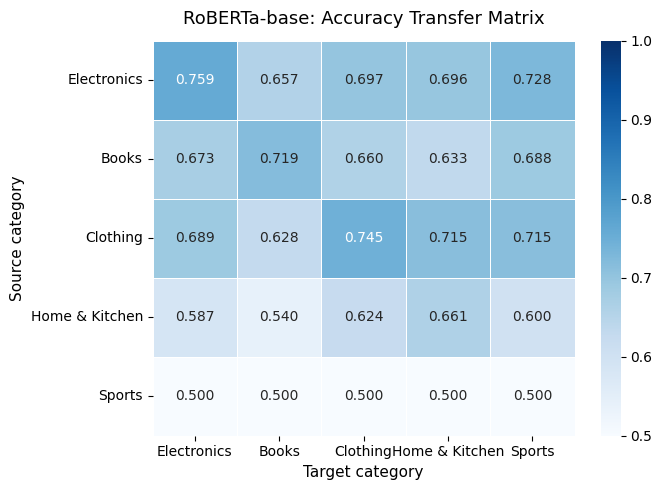

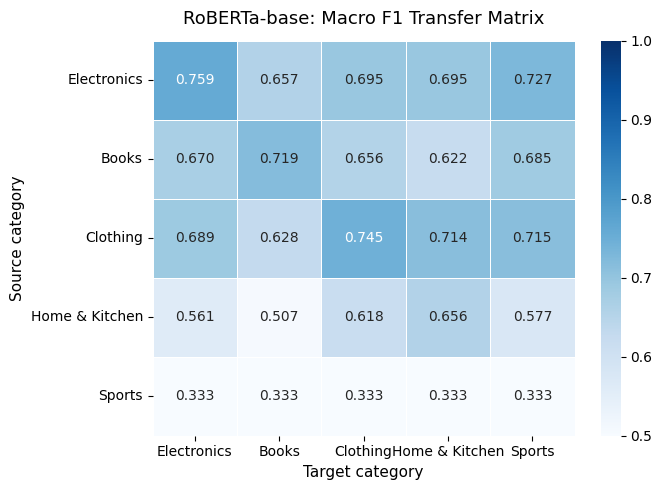

In [10]:
plot_heatmap(rob_acc, "RoBERTa-base: Accuracy Transfer Matrix", "heatmap_roberta.png")
plot_heatmap(rob_f1,  "RoBERTa-base: Macro F1 Transfer Matrix", "heatmap_roberta_f1.png")

## 2  DistilBERT-base-uncased

In [11]:
distilbert_tokenizer = DistilBertTokenizerFast.from_pretrained(DISTILBERT_NAME)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [12]:
def fine_tune_distilbert(source_cat: str) -> str:
    stem      = FILE_STEMS[source_cat]
    model_dir = f"{MODELS_DIR}/distilbert_{stem}"

    df_train = load_split(stem, "train")
    df_val   = load_split(stem, "val")

    train_ds = ReviewDataset(df_train["text"], df_train["label"], distilbert_tokenizer, MAX_LENGTH)
    val_ds   = ReviewDataset(df_val["text"],   df_val["label"],   distilbert_tokenizer, MAX_LENGTH)

    model = DistilBertForSequenceClassification.from_pretrained(DISTILBERT_NAME, num_labels=2)
    fp16  = torch.cuda.is_available()

    args = TrainingArguments(
        output_dir=model_dir,
        num_train_epochs=TRAIN_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        fp16=fp16,
        seed=RANDOM_SEED,
        logging_steps=50,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        processing_class=distilbert_tokenizer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
    )

    print(f"\nFine-tuning DistilBERT on {source_cat} ...")
    print(f"  train={len(df_train)}, val={len(df_val)}")
    trainer.train()
    trainer.save_model(model_dir)
    distilbert_tokenizer.save_pretrained(model_dir)
    print(f"  Saved -> {model_dir}")
    return model_dir

In [13]:
def evaluate_on_distilbert(model_dir: str, target_cat: str) -> dict:
    stem    = FILE_STEMS[target_cat]
    df_test = load_split(stem, "test")
    test_ds = ReviewDataset(df_test["text"], df_test["label"], distilbert_tokenizer, MAX_LENGTH)

    model = DistilBertForSequenceClassification.from_pretrained(model_dir)
    eval_args = TrainingArguments(
        output_dir="/tmp/eval_distilbert",
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        fp16=torch.cuda.is_available(),
        report_to="none",
    )
    trainer = Trainer(
        model=model,
        args=eval_args,
        compute_metrics=compute_metrics,
        processing_class=distilbert_tokenizer,
    )
    out    = trainer.predict(test_ds)
    preds  = np.argmax(out.predictions, axis=-1)
    y_true = df_test["label"].values
    return {
        "accuracy": accuracy_score(y_true, preds),
        "f1":       f1_score(y_true, preds, average="macro"),
        "y_true":   y_true,
        "y_pred":   preds,
    }

In [14]:
distilbert_results: dict[str, dict] = {}

for source_cat in CATEGORIES:
    model_dir = fine_tune_distilbert(source_cat)
    distilbert_results[source_cat] = {}

    for target_cat in CATEGORIES:
        res = evaluate_on_distilbert(model_dir, target_cat)
        distilbert_results[source_cat][target_cat] = res
        tag = "(in-domain)" if source_cat == target_cat else ""
        print(f"  {target_cat:<35} acc={res['accuracy']:.3f}  f1={res['f1']:.3f} {tag}")

print()
print("All DistilBERT training & evaluation complete.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Fine-tuning DistilBERT on Electronics ...
  train=3500, val=750


...

  Clothing_Shoes_and_Jewelry          acc=0.907  f1=0.907 


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  Home_and_Kitchen                    acc=0.881  f1=0.881 


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  Sports_and_Outdoors                 acc=0.927  f1=0.927 (in-domain)

All DistilBERT training & evaluation complete.


In [15]:
distil_acc = build_matrix(distilbert_results, "accuracy")
distil_f1  = build_matrix(distilbert_results, "f1")

distil_acc.to_csv(f"{RESULTS_DIR}/distilbert_transfer_matrix.csv")
distil_f1.to_csv(f"{RESULTS_DIR}/distilbert_transfer_matrix_f1.csv")

print("Saved DistilBERT transfer matrices.")
print()
print("DistilBERT accuracy matrix:")
print(distil_acc.to_string())

Saved DistilBERT transfer matrices.

DistilBERT accuracy matrix:
                Electronics     Books  Clothing  Home & Kitchen    Sports
Electronics        0.930667  0.842667  0.889333        0.896000  0.917333
Books              0.876000  0.917333  0.857333        0.850667  0.889333
Clothing           0.906667  0.858667  0.906667        0.908000  0.910667
Home & Kitchen     0.906667  0.860000  0.897333        0.920000  0.916000
Sports             0.917333  0.866667  0.906667        0.881333  0.926667


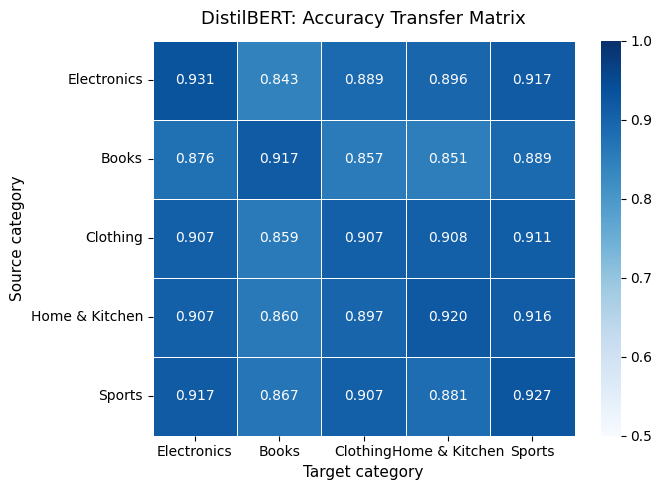

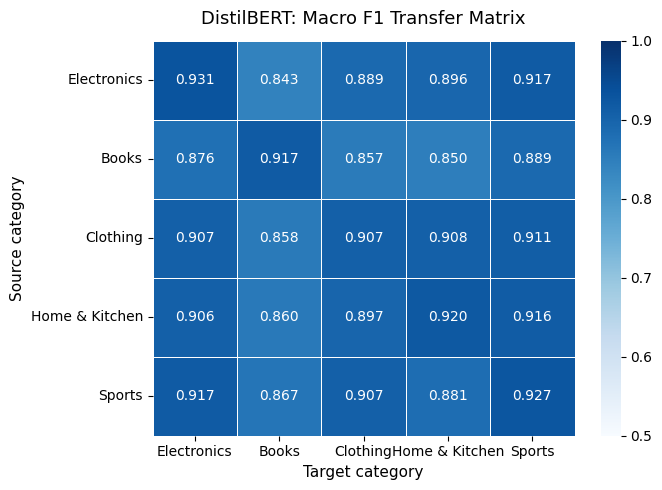

In [16]:
plot_heatmap(distil_acc, "DistilBERT: Accuracy Transfer Matrix", "heatmap_distilbert.png")
plot_heatmap(distil_f1,  "DistilBERT: Macro F1 Transfer Matrix", "heatmap_distilbert_f1.png")

## 3  Four-model comparison

Four-model comparison:
     Model  In-domain mean  Cross-domain mean  Degradation
    LogReg           0.903              0.844        0.059
       SVM           0.908              0.850        0.059
   RoBERTa           0.677              0.627        0.050
DistilBERT           0.920              0.888        0.033


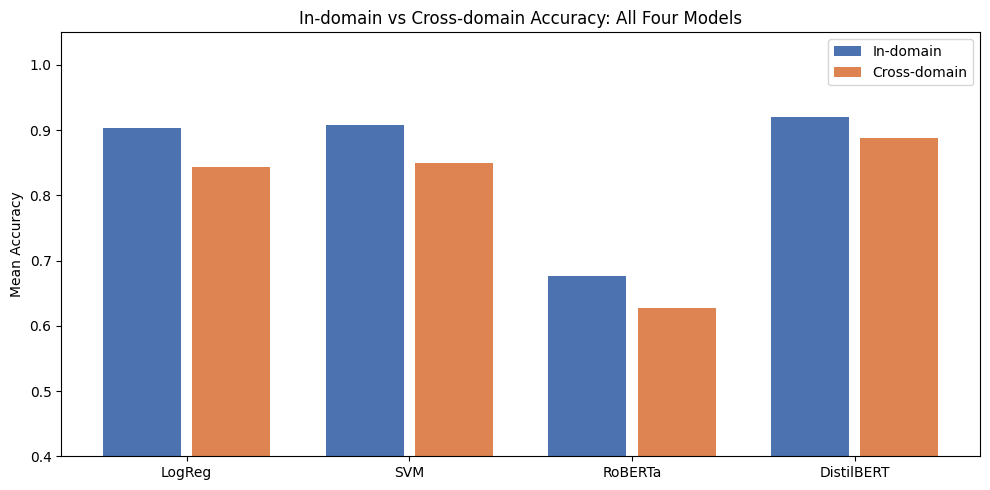

In [17]:
logreg_acc = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_logreg.csv", index_col=0)
svm_acc    = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_svm.csv",    index_col=0)

all_models = {"LogReg": logreg_acc, "SVM": svm_acc, "RoBERTa": rob_acc, "DistilBERT": distil_acc}

rows = []
for name, mat in all_models.items():
    m    = mat.values.astype(float)
    n    = m.shape[0]
    diag = np.diag(m)
    off  = m[~np.eye(n, dtype=bool)]
    rows.append({
        "Model":             name,
        "In-domain mean":    round(diag.mean(), 3),
        "Cross-domain mean": round(off.mean(),  3),
        "Degradation":       round(diag.mean() - off.mean(), 3),
    })

summary = pd.DataFrame(rows)
print("Four-model comparison:")
print(summary.to_string(index=False))

x = np.arange(len(all_models))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, summary["In-domain mean"],    0.35, label="In-domain",    color="#4c72b0")
ax.bar(x + 0.2, summary["Cross-domain mean"], 0.35, label="Cross-domain", color="#dd8452")
ax.set_xticks(x)
ax.set_xticklabels(summary["Model"])
ax.set_ylim(0.4, 1.05)
ax.set_ylabel("Mean Accuracy")
ax.set_title("In-domain vs Cross-domain Accuracy: All Four Models")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/accuracy_comparison_all_models.png", dpi=150)
plt.show()